## Modelo Extreme Gradient Boosting

#### _Importar librerías_

In [9]:
import datetime
import os
from time import strftime
import numpy as np
from datetime import timedelta
from itertools import product
from datetime import datetime
import shutil
import pyodbc
import pandas as pd
import pandasql as psql
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import os
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank, select_order
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import RobustScaler,StandardScaler 

scaler = StandardScaler()

user = os.getlogin()

#### _Importar los dato_

In [97]:
# Se agrega un for para importar los datos del mismo file para cada materia prima
for i in ['soya','maiz','trigo']:
    locals()[i] = pd.read_excel("C:\\Users\\"+ user +"\\OneDrive\\igor\\1. Posgrado\\2. Maestría - MEC\\3. Trabajo de grado\\1. Trabajo-Maestr-a-MEC\\1. Datos\\precios_filtrados_por_regimenes.xlsx",
                               sheet_name = i,
                               index_col = 0)
    # Prueba con datos mensuales (ME) o semanales (W)
    # locals()[i] = locals()[i].resample('ME').mean() .interpolate(method='linear')

#### _Generar el modelo_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

📌 soya — Mejores parámetros:
{'subsample': 0.8, 'reg_lambda': 0.325, 'reg_alpha': 0.16999999999999998, 'n_estimators': 2000, 'max_depth': 20, 'learning_rate': 0.2677777777777778, 'gamma': 5, 'colsample_bytree': 0.8}
🔎 RMSE: 86.4595 | MSE: 7475.2523 | MAE: 81.8804 | MAPE: 9.1758%


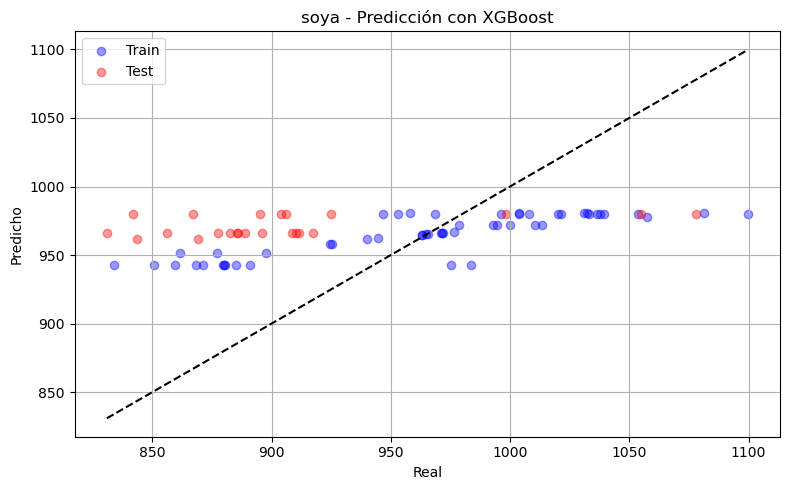

Fitting 5 folds for each of 30 candidates, totalling 150 fits

📌 maiz — Mejores parámetros:
{'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0.12, 'n_estimators': 500, 'max_depth': 20, 'learning_rate': 0.07444444444444444, 'gamma': 1, 'colsample_bytree': 1.0}
🔎 RMSE: 31.3210 | MSE: 981.0065 | MAE: 23.4635 | MAPE: 6.3501%


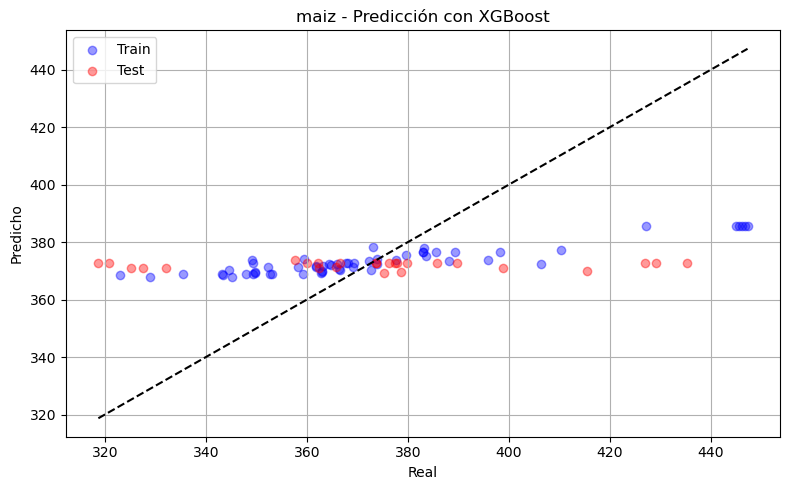

Fitting 5 folds for each of 30 candidates, totalling 150 fits

📌 trigo — Mejores parámetros:
{'subsample': 0.8, 'reg_lambda': 0.325, 'reg_alpha': 0.16999999999999998, 'n_estimators': 2000, 'max_depth': 20, 'learning_rate': 0.2677777777777778, 'gamma': 5, 'colsample_bytree': 0.8}
🔎 RMSE: 53.2146 | MSE: 2831.7980 | MAE: 46.9105 | MAPE: 8.9095%


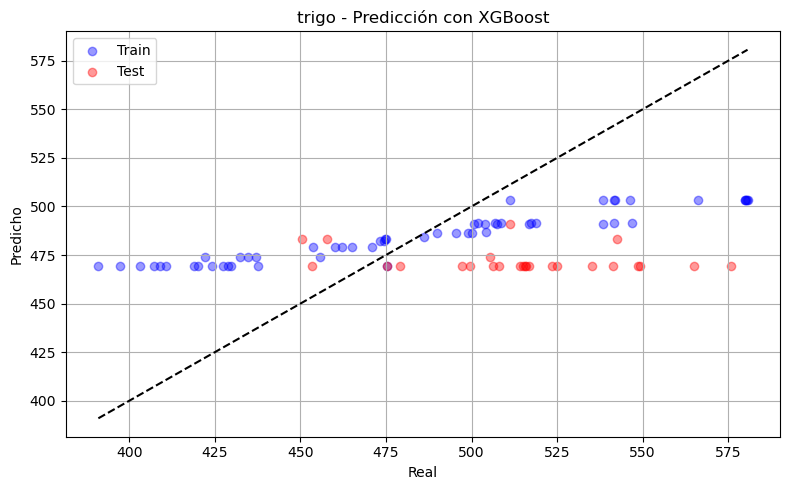


📊 Resumen de resultados:
  commodity       rmse          mse        mae      mape  \
0      soya  86.459541  7475.252267  81.880387  0.091758   
1      maiz  31.321023   981.006458  23.463522  0.063501   
2     trigo  53.214641  2831.798030  46.910466  0.089095   

                                              params  
0  {'subsample': 0.8, 'reg_lambda': 0.325, 'reg_a...  
1  {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alp...  
2  {'subsample': 0.8, 'reg_lambda': 0.325, 'reg_a...  


In [93]:
# Modelo XGB


variables = {'soya':['Stock/Consumo','petroleo','diesel'], 
             'maiz':['Stock/Consumo','petroleo', 'engorde', 'diesel','gas_natural'],
             'trigo':['Stock/Consumo','petroleo', 'engorde', 'diesel','gas_natural']}

# Diccionarios en lugar de locals()
train_features, test_features = {}, {}
train_targets, test_targets = {}, {}
train_predictions, test_predictions = {}, {}
hiper = pd.DataFrame()
resultados = []

# Escalador (puede cambiarse a RobustScaler si hay outliers)
scaler = StandardScaler()

# Modelo base
gbm = xgb.XGBRegressor(objective='reg:squarederror')  # 👈 más apropiado para datos sin log

# Búsqueda de hiperparámetros
parametros = {
    "n_estimators": [300, 500, 1000, 2000],
    "learning_rate": np.linspace(0.01, 0.3, 10),
    "max_depth": [10, 20, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": np.arange(0.1, 0.5, 0.01),
    "gamma": [0, 1, 5],                    # 👈 penaliza divisiones pobres
    # "reg_alpha": np.linspace(0.001, 0.05, 5),  # L1 regularization
    "reg_lambda": np.linspace(0.1, 1.0, 5)     # L2 regularization
}

for i in variables.keys():
    # Separar features y target
    df = locals()[i].copy()
    X = df.drop(columns=[i, "Domestic Total", "Ending Stocks"])
    y = df[i]

    # Escalado de X
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    
    from scipy.stats import zscore
    
    z_scores = X_scaled .apply(zscore)
    
    X_scaled  = X_scaled.mask((z_scores > 3) | (z_scores < -3))
    
    # Separar train/test
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, shuffle=False)
    train_features[i], test_features[i] = X_train, X_test
    train_targets[i], test_targets[i] = y_train, y_test

    # Búsqueda aleatoria
    search = RandomizedSearchCV(
        estimator=gbm,
        param_distributions=parametros,
        n_iter=30,
        scoring='neg_mean_squared_error',
        cv=5,
        verbose=1,
        random_state=42
    )
    search.fit(X_train, y_train)

    print(f"\n📌 {i} — Mejores parámetros:")
    print(search.best_params_)

    # Entrenamiento con mejores hiperparámetros
    xg_reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=search.best_params_["n_estimators"],
        learning_rate=search.best_params_["learning_rate"],
        max_depth=search.best_params_["max_depth"],
        subsample=search.best_params_["subsample"],
        colsample_bytree=search.best_params_["colsample_bytree"],
        reg_alpha=search.best_params_["reg_alpha"],
        early_stopping_rounds = 50
    )

    xg_reg.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        # early_stopping_rounds=20,
        verbose=False
    )

    # Predicción
    y_train_pred = xg_reg.predict(X_train)
    y_test_pred = xg_reg.predict(X_test)
    train_predictions[i] = y_train_pred
    test_predictions[i] = y_test_pred

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mse = mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    mape = mean_absolute_percentage_error(y_test, y_test_pred)

    print(f"🔎 RMSE: {rmse:.4f} | MSE: {mse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.4%}")

    # Guardar resumen
    resultados.append({
        "commodity": i,
        "rmse": rmse,
        "mse": mse,
        "mae": mae,
        "mape": mape,
        "params": search.best_params_
    })

    # Gráfico
    plt.figure(figsize=(8, 5))
    plt.scatter(y_train, y_train_pred, alpha=0.4, label="Train", color="blue")
    plt.scatter(y_test, y_test_pred, alpha=0.4, label="Test", color="red")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
    plt.xlabel("Real")
    plt.ylabel("Predicho")
    plt.title(f"{i} - Predicción con XGBoost")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Mostrar resumen general
df_resultados = pd.DataFrame(resultados)
print("\n📊 Resumen de resultados:")
print(df_resultados)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

📌 soya — Mejores parámetros:
{'subsample': 1.0, 'reg_lambda': 0.325, 'reg_alpha': 0.19999999999999996, 'n_estimators': 300, 'max_depth': 20, 'learning_rate': 0.1388888888888889, 'gamma': 1, 'colsample_bytree': 0.6}
🔎 RMSE: 66.9711 | MSE: 4485.1268 | MAE: 60.7661 | MAPE: 6.8320%


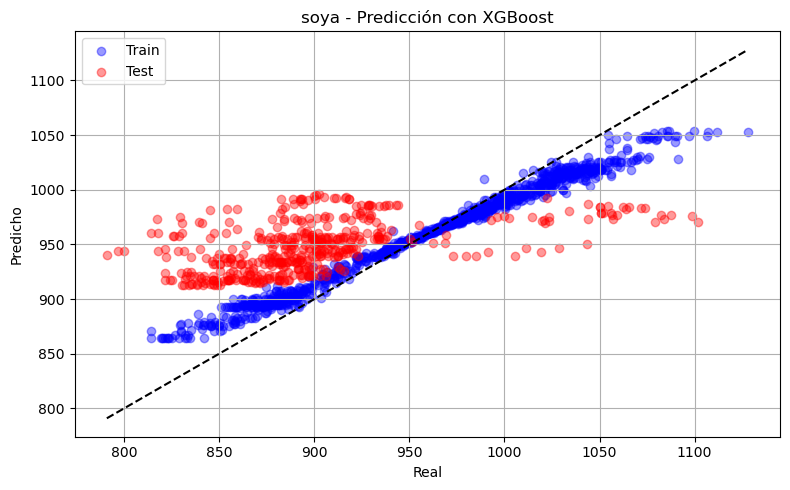

Fitting 5 folds for each of 30 candidates, totalling 150 fits

📌 maiz — Mejores parámetros:
{'subsample': 0.8, 'reg_lambda': 0.55, 'reg_alpha': 0.33999999999999986, 'n_estimators': 2000, 'max_depth': 20, 'learning_rate': 0.2677777777777778, 'gamma': 0, 'colsample_bytree': 0.8}
🔎 RMSE: 34.9958 | MSE: 1224.7083 | MAE: 27.6122 | MAPE: 7.4377%


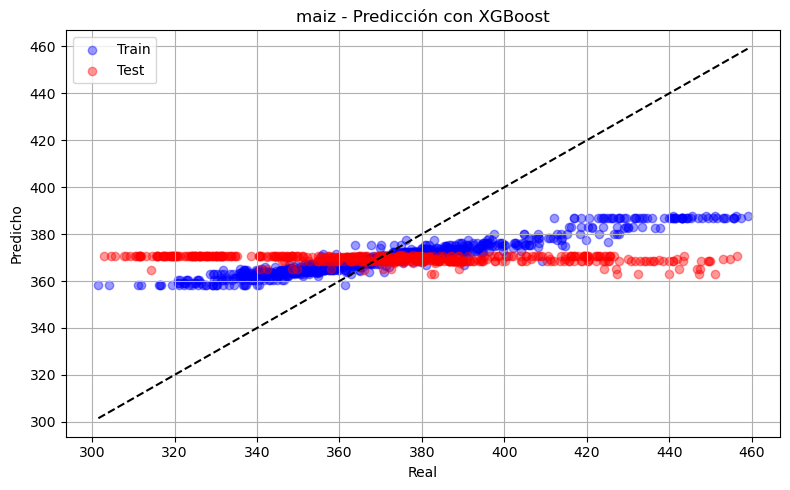

Fitting 5 folds for each of 30 candidates, totalling 150 fits

📌 trigo — Mejores parámetros:
{'subsample': 0.6, 'reg_lambda': 0.775, 'reg_alpha': 0.47999999999999976, 'n_estimators': 2000, 'max_depth': 20, 'learning_rate': 0.1711111111111111, 'gamma': 5, 'colsample_bytree': 0.6}
🔎 RMSE: 49.6286 | MSE: 2463.0022 | MAE: 42.9770 | MAPE: 8.2033%


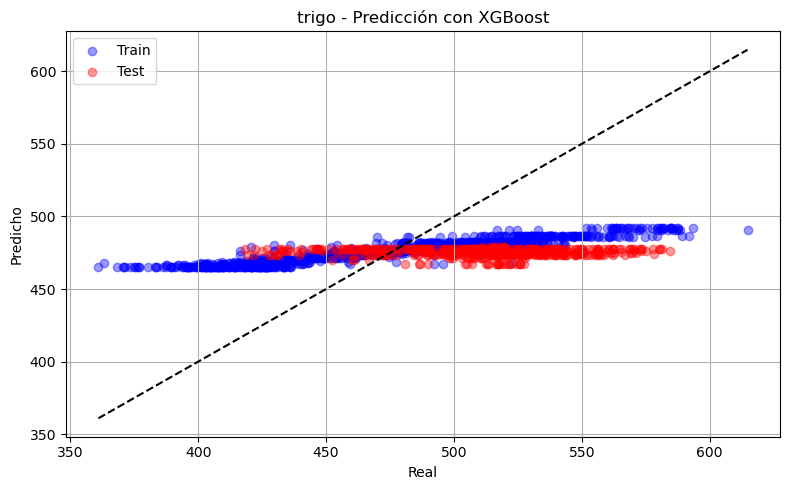


📊 Resumen de resultados:
  commodity       rmse          mse        mae      mape  \
0      soya  66.971089  4485.126762  60.766136  0.068320   
1      maiz  34.995833  1224.708311  27.612218  0.074377   
2     trigo  49.628643  2463.002209  42.976959  0.082033   

                                              params  
0  {'subsample': 1.0, 'reg_lambda': 0.325, 'reg_a...  
1  {'subsample': 0.8, 'reg_lambda': 0.55, 'reg_al...  
2  {'subsample': 0.6, 'reg_lambda': 0.775, 'reg_a...  


In [58]:
# Modelo XGB


variables = {'soya':['Stock/Consumo','petroleo','diesel'], 
             'maiz':['Stock/Consumo','petroleo', 'engorde', 'diesel','gas_natural'],
             'trigo':['Stock/Consumo','petroleo', 'engorde', 'diesel','gas_natural']}

# Diccionarios en lugar de locals()
train_features, test_features = {}, {}
train_targets, test_targets = {}, {}
train_predictions, test_predictions = {}, {}
hiper = pd.DataFrame()
resultados = []

# Escalador (puede cambiarse a RobustScaler si hay outliers)
scaler = StandardScaler()

# Modelo base
gbm = xgb.XGBRegressor(objective='reg:squarederror')  # 👈 más apropiado para datos sin log

# Búsqueda de hiperparámetros
parametros = {
    "n_estimators": [300, 500, 1000, 2000],
    "learning_rate": np.linspace(0.01, 0.3, 10),
    "max_depth": [10, 20, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": np.arange(0.1, 0.5, 0.01),
    "gamma": [0, 1, 5],                    # 👈 penaliza divisiones pobres
    # "reg_alpha": np.linspace(0.001, 0.05, 5),  # L1 regularization
    "reg_lambda": np.linspace(0.1, 1.0, 5)     # L2 regularization
}

for i in variables.keys():
    # Separar features y target
    df = locals()[i].copy()
    X = df.drop(columns=[i, "Domestic Total", "Ending Stocks"])
    y = df[i]

    # Escalado de X
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    
    from scipy.stats import zscore
    
    z_scores = X_scaled .apply(zscore)
    
    X_scaled  = X_scaled.mask((z_scores > 3) | (z_scores < -3))
    
    # Separar train/test
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, shuffle=False)
    train_features[i], test_features[i] = X_train, X_test
    train_targets[i], test_targets[i] = y_train, y_test

    # Búsqueda aleatoria
    search = RandomizedSearchCV(
        estimator=gbm,
        param_distributions=parametros,
        n_iter=30,
        scoring='neg_mean_squared_error',
        cv=5,
        verbose=1,
        random_state=42
    )
    search.fit(X_train, y_train)

    print(f"\n📌 {i} — Mejores parámetros:")
    print(search.best_params_)

    # Entrenamiento con mejores hiperparámetros
    xg_reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=search.best_params_["n_estimators"],
        learning_rate=search.best_params_["learning_rate"],
        max_depth=search.best_params_["max_depth"],
        subsample=search.best_params_["subsample"],
        colsample_bytree=search.best_params_["colsample_bytree"],
        reg_alpha=search.best_params_["reg_alpha"],
        early_stopping_rounds = 50
    )

    xg_reg.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        # early_stopping_rounds=20,
        verbose=False
    )

    # Predicción
    y_train_pred = xg_reg.predict(X_train)
    y_test_pred = xg_reg.predict(X_test)
    train_predictions[i] = y_train_pred
    test_predictions[i] = y_test_pred

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mse = mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    mape = mean_absolute_percentage_error(y_test, y_test_pred)

    print(f"🔎 RMSE: {rmse:.4f} | MSE: {mse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.4%}")

    # Guardar resumen
    resultados.append({
        "commodity": i,
        "rmse": rmse,
        "mse": mse,
        "mae": mae,
        "mape": mape,
        "params": search.best_params_
    })

    # Gráfico
    plt.figure(figsize=(8, 5))
    plt.scatter(y_train, y_train_pred, alpha=0.4, label="Train", color="blue")
    plt.scatter(y_test, y_test_pred, alpha=0.4, label="Test", color="red")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
    plt.xlabel("Real")
    plt.ylabel("Predicho")
    plt.title(f"{i} - Predicción con XGBoost")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Mostrar resumen general
df_resultados = pd.DataFrame(resultados)
print("\n📊 Resumen de resultados:")
print(df_resultados)

#### _Comparar estimado vs real del modelo XGBoosting_

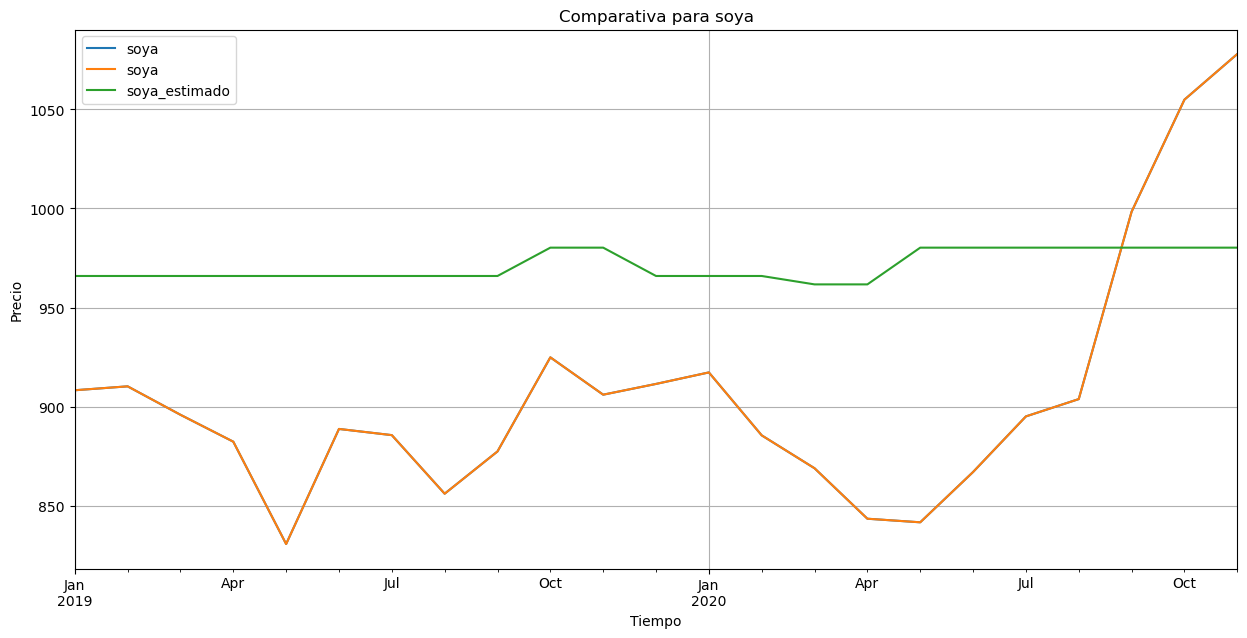

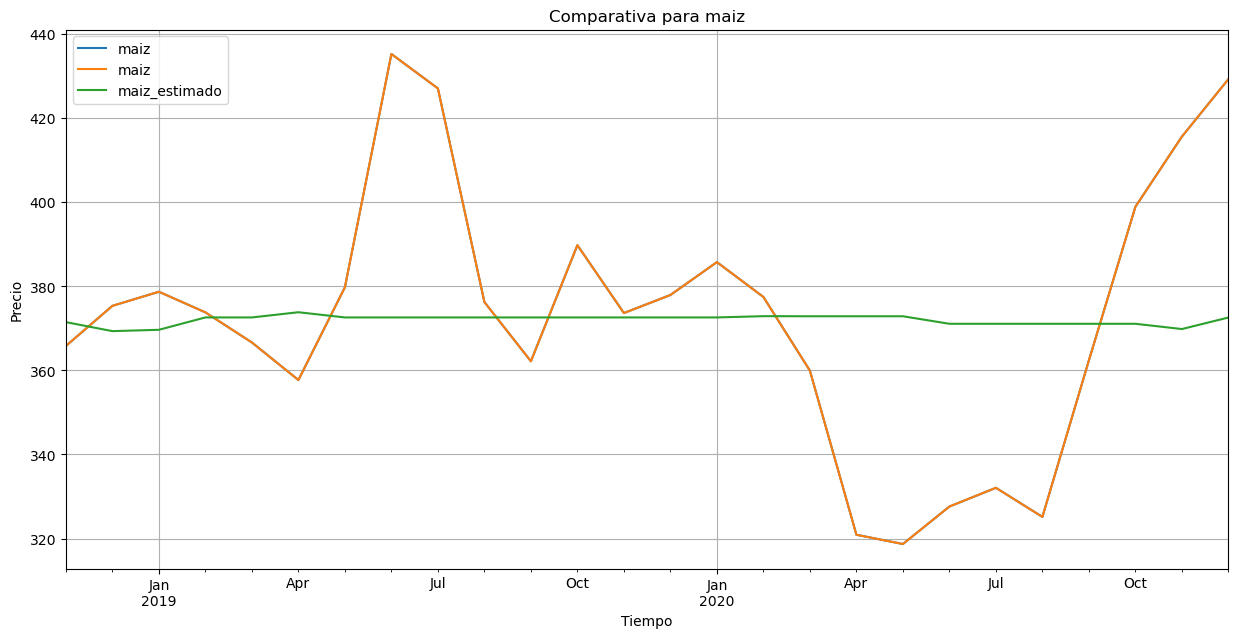

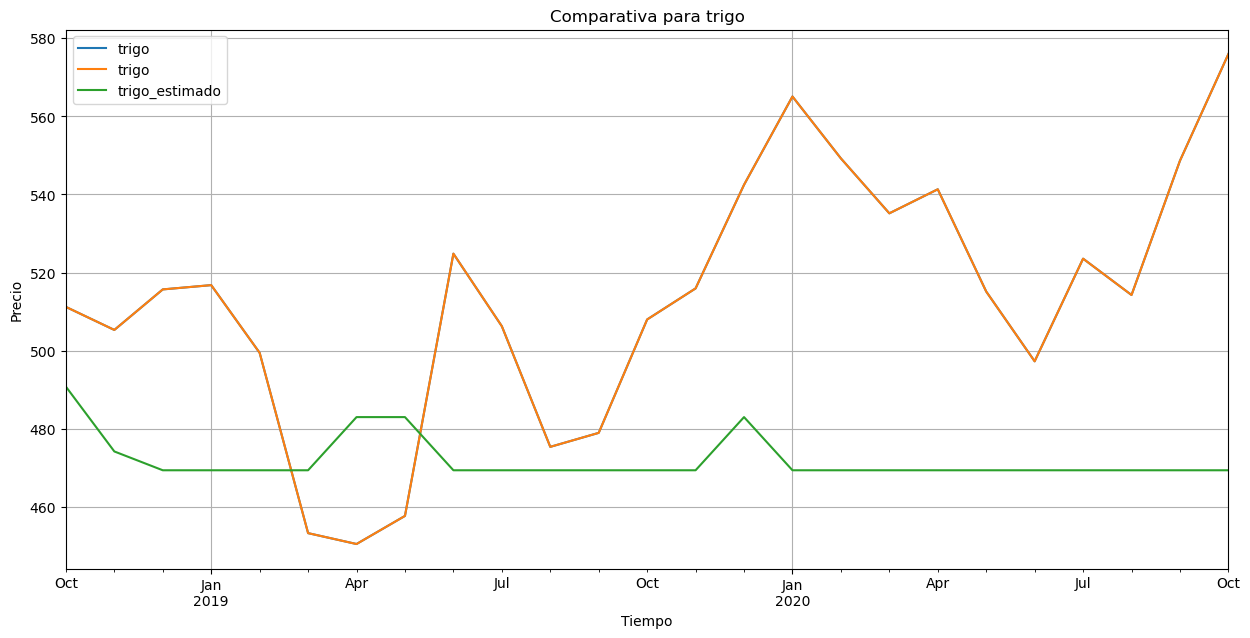

In [95]:
# Crear la nueva serie de precios utilizando los retornos estimados
for i in variables.keys():
    locals()["precio" + i] = locals()[i][len(train_features[i]):][i]
    
    locals()[i+"_estimado"] = pd.DataFrame({i+"_estimado":test_predictions[i] },index=pd.DataFrame(test_targets[i]).index)
    # locals()[i+"_estimado"] = pd.DataFrame({i+"_estimado":test_predictions[i]},index=pd.DataFrame(locals()["test_targets_" + i]).index)
    
    # Crear los precios estimados
    locals()["comparacion_" + i] = pd.concat([locals()["precio" + i], 
                            test_targets[i],                           
                            locals()[i+"_estimado"]]
                                         ,axis=1)
    
    
    locals()["comparacion_" + i][[i,i + "_estimado"]].iloc[0:45,:].plot(figsize=(15,7),grid=True)
    plt.xlabel('Tiempo') 
    plt.ylabel('Precio')
    plt.title("Comparativa para " + i)
    plt.show()